# Grid Cell Simulation and Path Lifting

This notebook demonstrates the full pipeline:
1. Simulate a random walk trajectory in a 2D world
2. Simulate grid cell activity from the trajectory
3. Recover the trajectory via toroidal coordinate extraction and path lifting
4. Compare the recovered trajectory to the original

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import binned_statistic_2d

# Ensure repo-root imports work no matter where the notebook kernel starts.
repo_root = Path.cwd()
if not (repo_root / "constants.py").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from trajectory import World, visualize_trajectory, random_walk
from grid_cell_simulation import preprocess, simulation
from pipelines import recover_traj_pipeline, compare_lifted_pipeline, plot_trajectory_comparison
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance_upgrade
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat
from affine_transform.score_mismatch import segmental_mismatch

## 1. Simulate a Random Walk Trajectory

In [2]:
# --- Simulate a new trajectory ---
WORLD_SIZE = (100, 100)
# HOLES = None
HOLES = [(30, 30, 70, 70)]  # one square hole in the center
#HOLES = [(10, 10, 45, 45), (55, 55, 90, 90)]
STEP_SIZE = 2
traj_length = 25000
world = World(WORLD_SIZE, holes=HOLES, step_size=STEP_SIZE)
trace = random_walk(traj_length, world, save=False, no_warnings=True)

print(f"Trajectory shape: {trace.shape}")
print(f"World size: {world.size}, holes: {world.holes}, step_size: {world.step_size}")

  0%|          | 0/24999 [00:00<?, ?it/s]

100%|██████████| 24999/24999 [00:23<00:00, 1043.62it/s]

Trajectory shape: (25000, 2)
World size: (100, 100), holes: [(30, 30, 70, 70)], step_size: 2


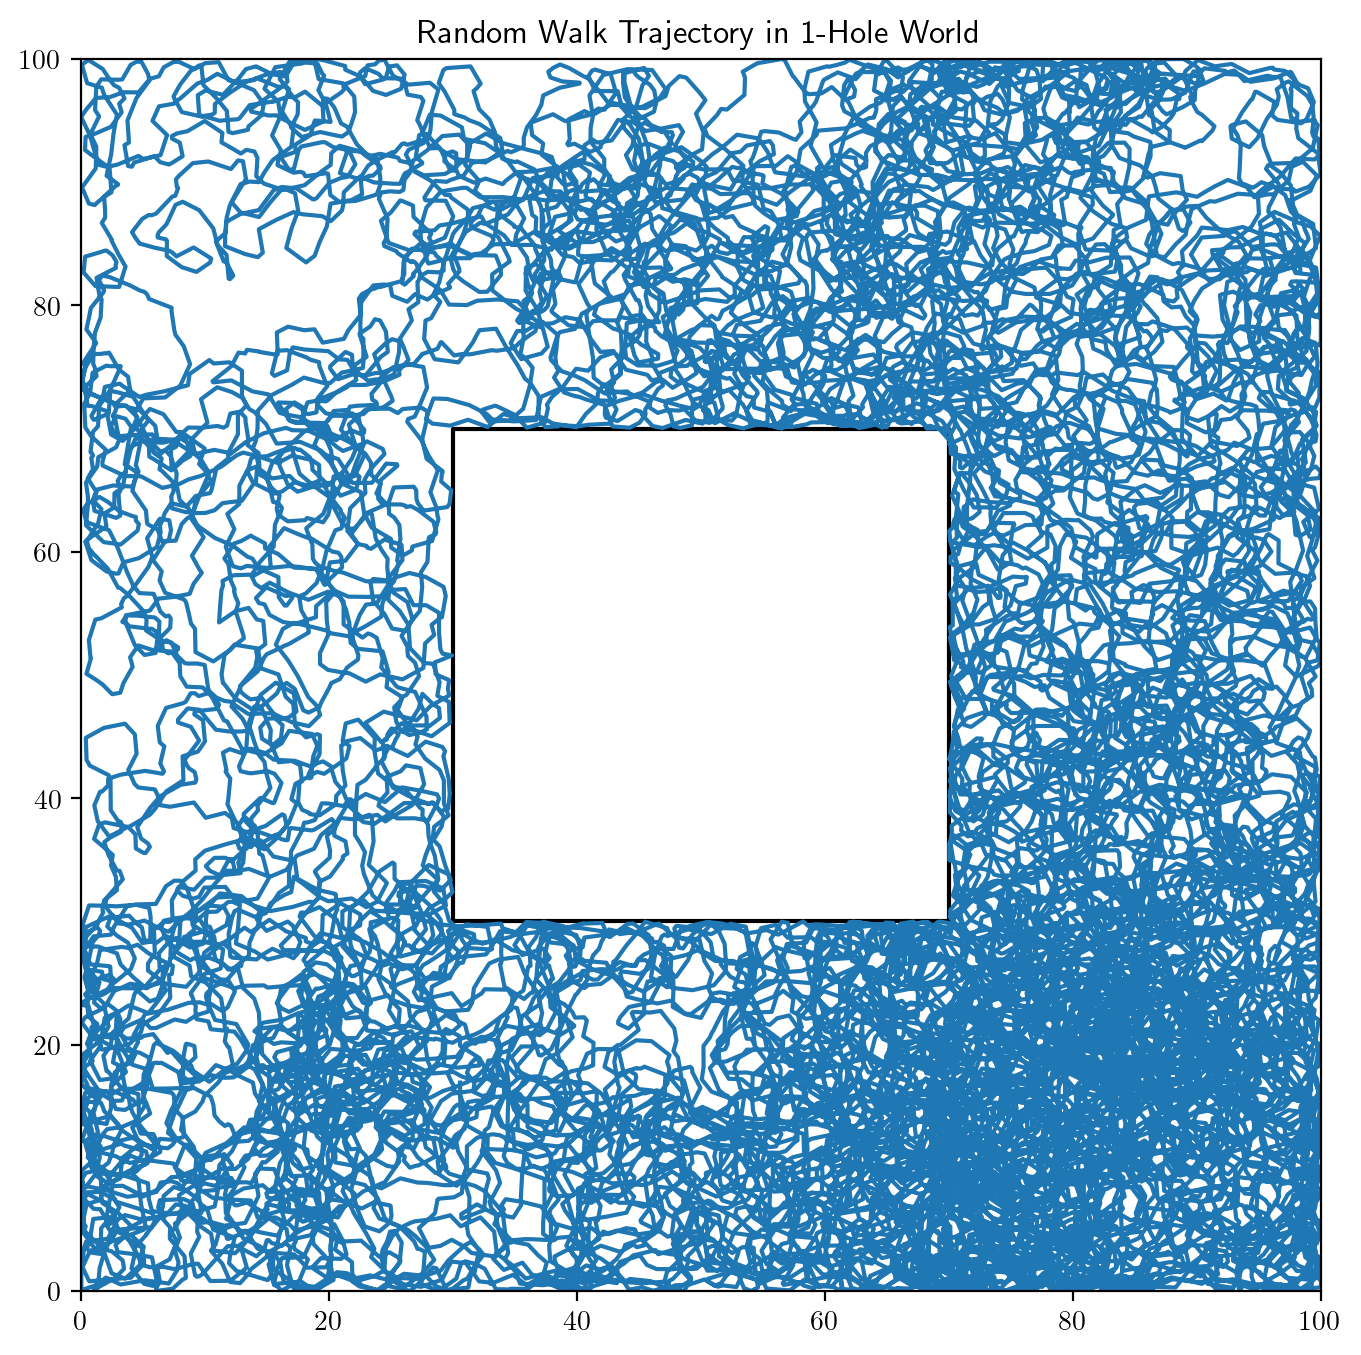

In [3]:
visualize_trajectory(world, trace, save=False, show=True)

## 2. Simulate Grid Cell Activity

In [4]:
processed_trace = preprocess(trace, goal=600000)
print(f"Processed trace shape: {processed_trace.shape}")


Processed trace shape: (600000, 2)


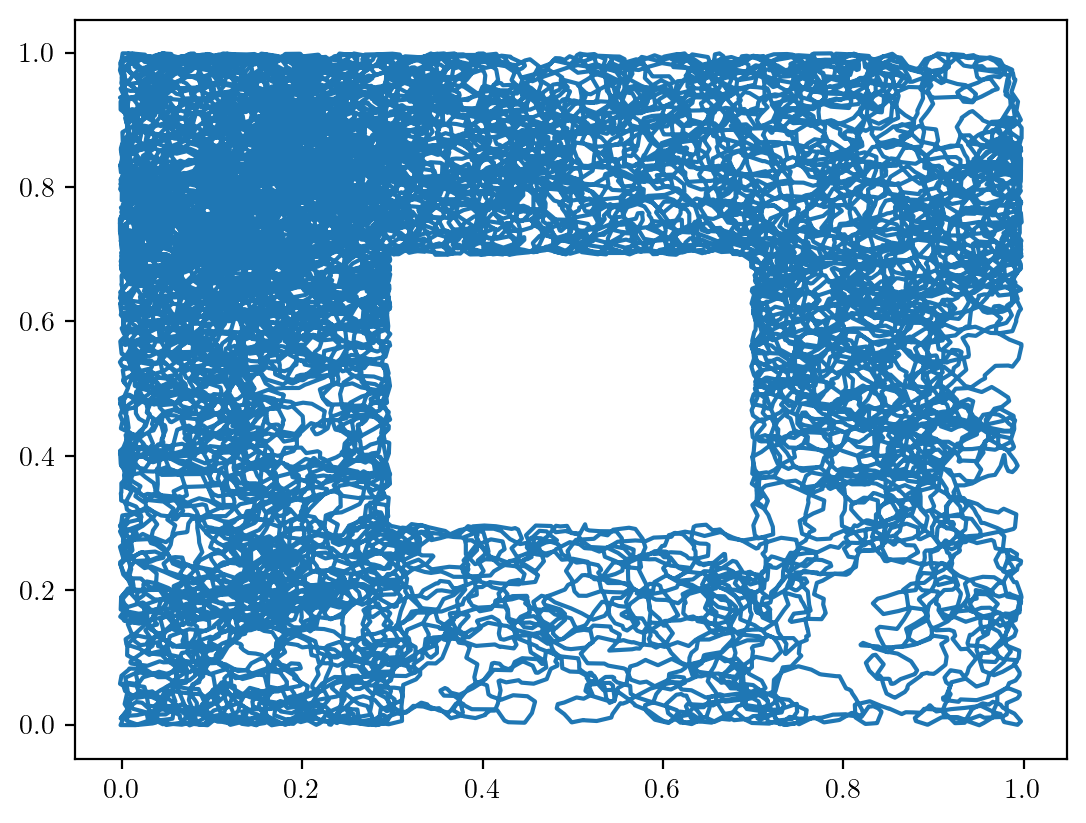

In [ ]:
visualize_trajectory(world, processed_trace, save=False, show=True)

In [6]:
grid_activity = simulation(processed_trace)

print(f"Grid activity shape: {grid_activity.shape}  (n_cells x n_timesteps)")

# The simulation computes speeds via diff, producing one fewer timestep than the trace.
# Trim processed_trace to align with grid_activity.
assert processed_trace.shape[0] - grid_activity.shape[1] == 1, \
    f"Unexpected shape mismatch: trace={processed_trace.shape[0]}, activity={grid_activity.shape[1]}"
processed_trace = processed_trace[:grid_activity.shape[1]]
print(f"Trimmed processed trace shape: {processed_trace.shape}")

Running simulation...


  1%|          | 3568/599999 [00:01<02:19, 4279.35it/s]

100%|██████████| 599999/599999 [01:06<00:00, 8959.77it/s] 

Grid activity shape: (2464, 599999)  (n_cells x n_timesteps)
Trimmed processed trace shape: (599999, 2)


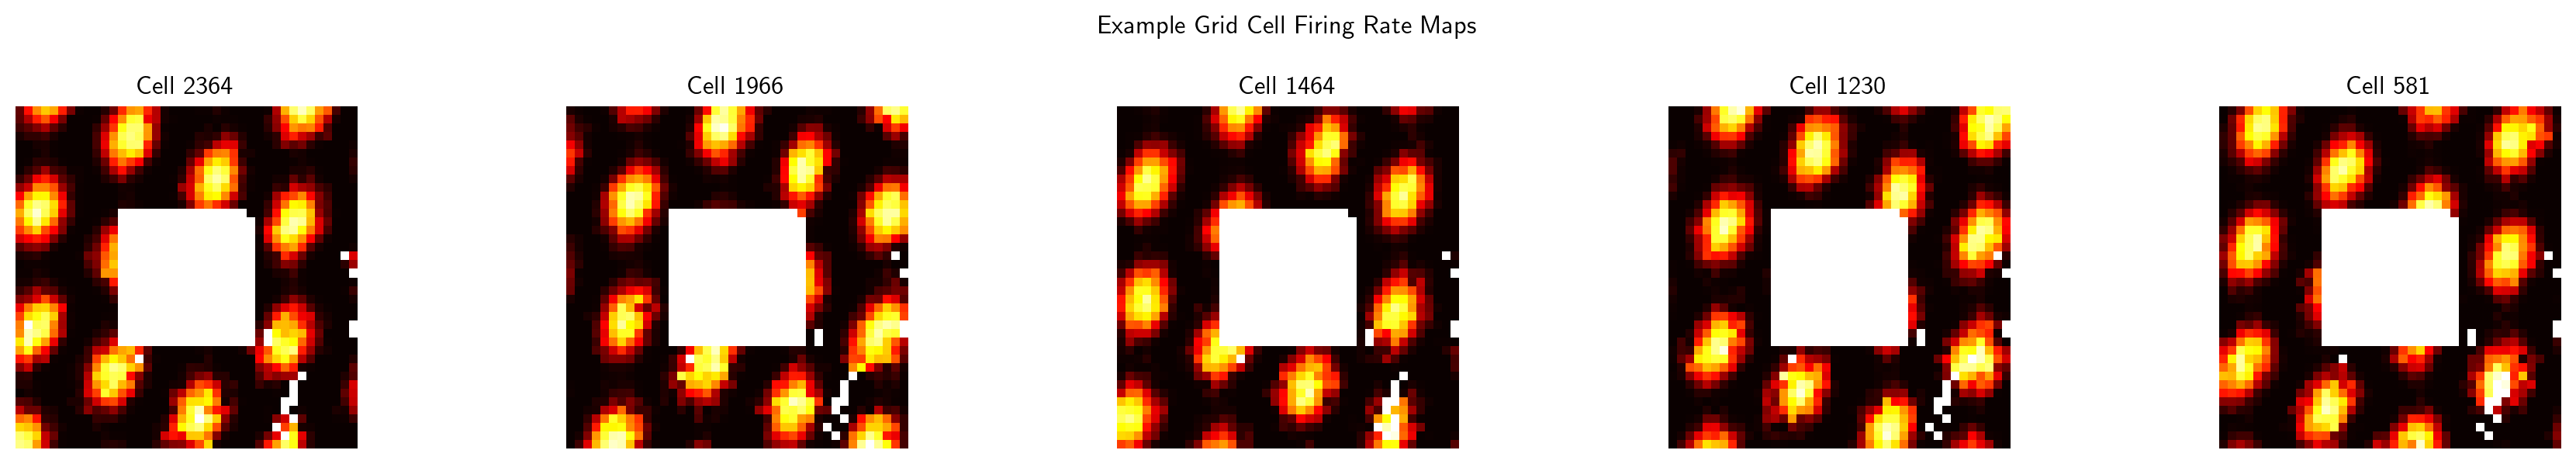

In [7]:
# Visualize a few example grid cell firing rate maps
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
sample_cells = np.random.choice(grid_activity.shape[0], 5, replace=False)
for ax, cell_idx in zip(axes, sample_cells):
    rate_map, _, _, _ = binned_statistic_2d(
        processed_trace[:, 0], processed_trace[:, 1],
        grid_activity[cell_idx], statistic='mean', bins=40
    )
    ax.imshow(rate_map.T, origin='lower', cmap='hot')
    ax.set_title(f'Cell {cell_idx}')
    ax.axis('off')
plt.suptitle('Example Grid Cell Firing Rate Maps')
plt.tight_layout()
plt.show()

## 3. Recover Trajectory via Toroidal Coords + Path Lifting

In [36]:
tor_coord_dreimac, lifted_coord_dreimac = recover_traj_pipeline(grid_activity)
print(f"Toroidal coord shape: {tor_coord_dreimac.shape}")
print(f"Lifted coord shape:   {lifted_coord_dreimac.shape}")

DISTANCE_THRESHOLD: 4.215035856225906
Toroidal coord shape: (599999, 2)
Lifted coord shape:   (599999, 2)


In [37]:
tor_coord_gardner, lifted_coord_gardner = recover_traj_pipeline(grid_activity, method='gardner')
print(f"Toroidal coord shape: {tor_coord_gardner.shape}")
print(f"Lifted coord shape:   {lifted_coord_gardner.shape}")

/home/yyao01/GridPathLifting/toroidal_coordinates/Gardner_toroidal.py:155: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


DISTANCE_THRESHOLD: 4.264552084745165
Toroidal coord shape: (599999, 2)
Lifted coord shape:   (599999, 2)


In [38]:
tor_coord = tor_coord_gardner

In [39]:
# using the newsest method that IY wrote.
lifted_coord = toroidal_lifting_distance_upgrade(tor_coord)

DISTANCE_THRESHOLD: 4.264552084745165


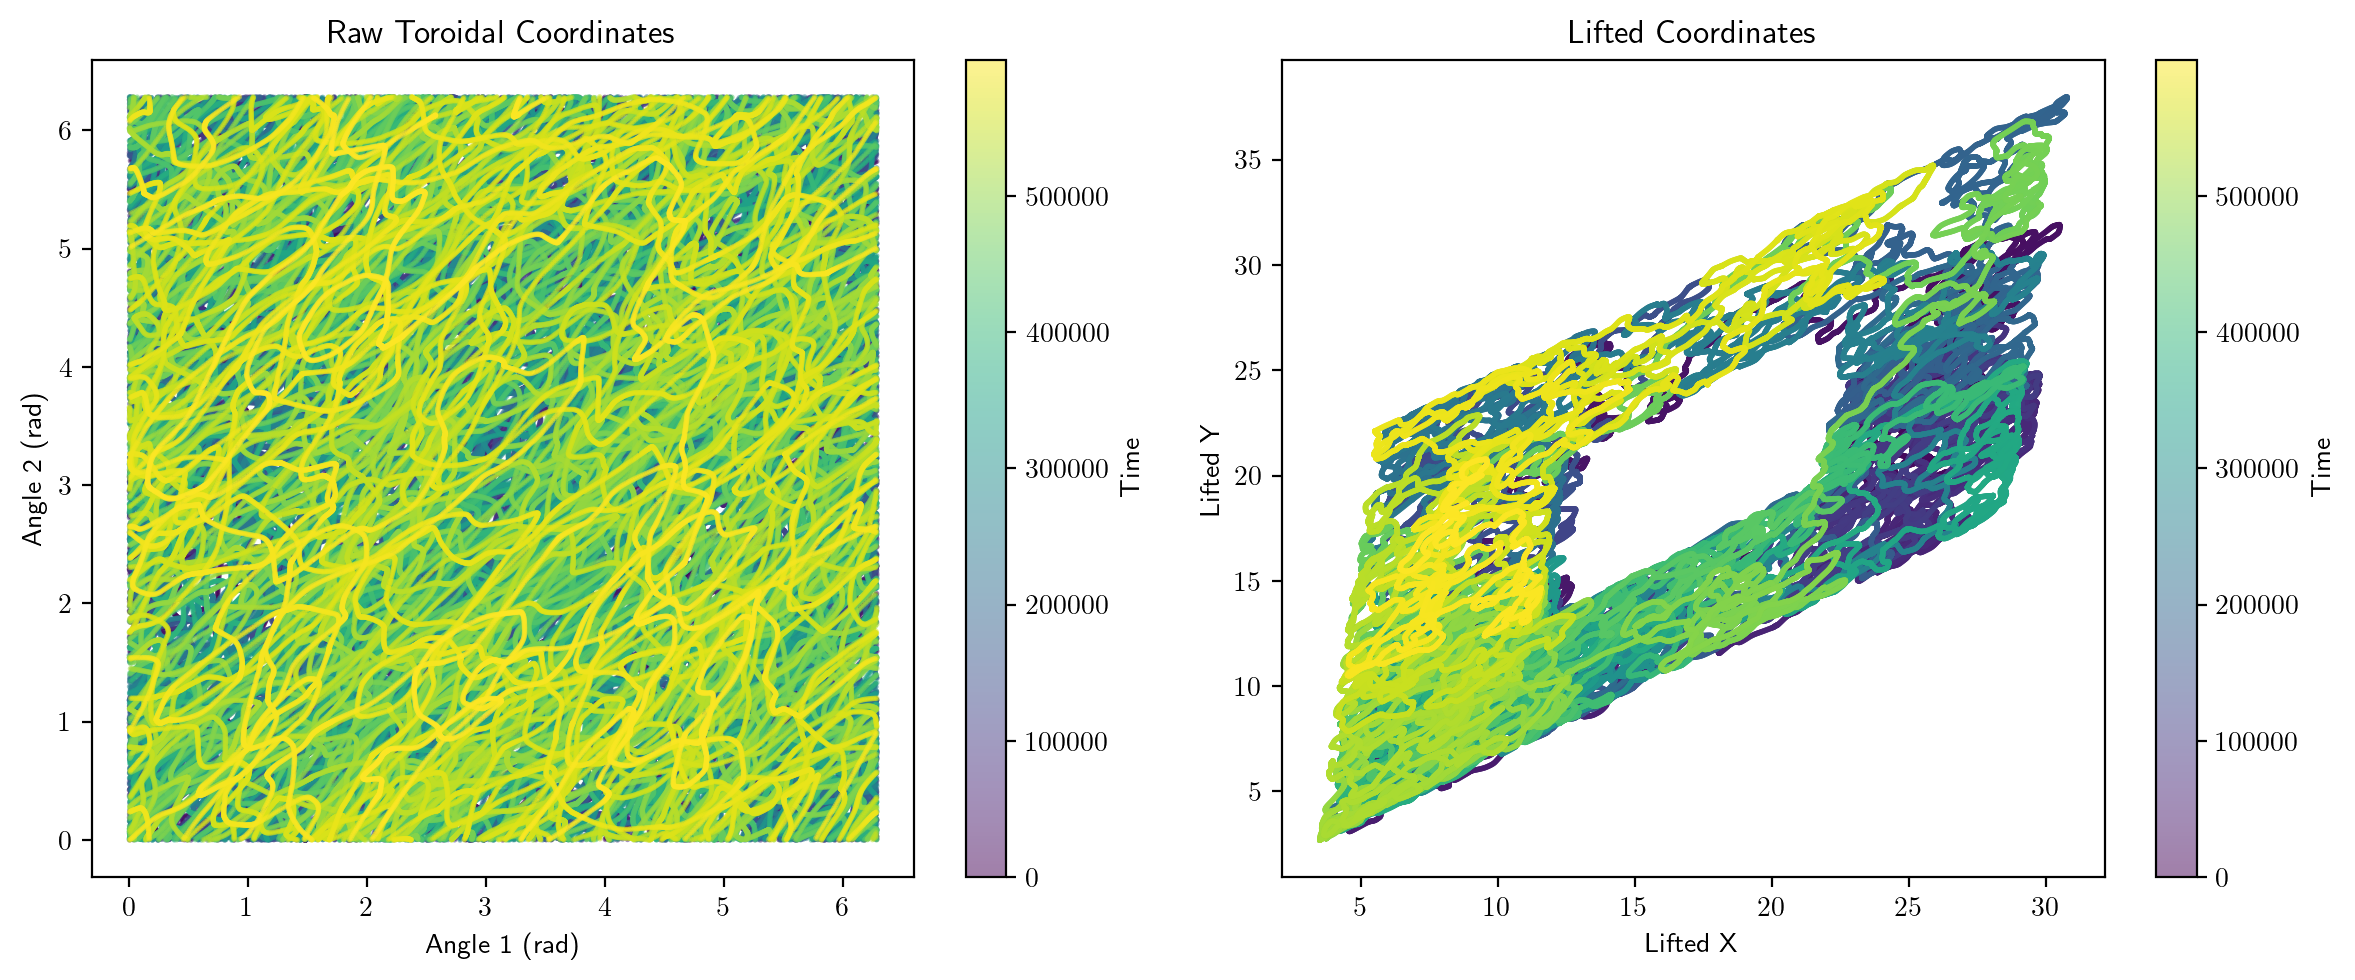

In [40]:
# Visualize raw toroidal coordinates (on the torus)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sc1 = ax1.scatter(tor_coord[:, 0], tor_coord[:, 1],
                  c=np.arange(len(tor_coord)), cmap='viridis', s=1, alpha=0.5)
ax1.set_title('Raw Toroidal Coordinates')
ax1.set_xlabel('Angle 1 (rad)')
ax1.set_ylabel('Angle 2 (rad)')
plt.colorbar(sc1, ax=ax1, label='Time')

sc2 = ax2.scatter(lifted_coord[:, 0], lifted_coord[:, 1],
                  c=np.arange(len(lifted_coord)), cmap='viridis', s=1, alpha=0.5)
ax2.set_title('Lifted Coordinates')
ax2.set_xlabel('Lifted X')
ax2.set_ylabel('Lifted Y')
plt.colorbar(sc2, ax=ax2, label='Time')

plt.tight_layout()
plt.show()

## 4. Compare Recovered Trajectory to Original

In [41]:
lifted_coord_transformed_dreimac, score_dreimac = compare_lifted_pipeline(lifted_coord_dreimac, processed_trace, world_size=max(world.size))

Mismatch score: 0.0001657362765100182


In [42]:
lifted_coord_transformed_gardner, score_gardner = compare_lifted_pipeline(lifted_coord_gardner, processed_trace, world_size=max(world.size))

Mismatch score: 0.00015484094225677226


In [43]:
lifted_coord_transformed = lifted_coord_transformed_gardner

/home/yyao01/GridPathLifting/pipelines.py:249: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


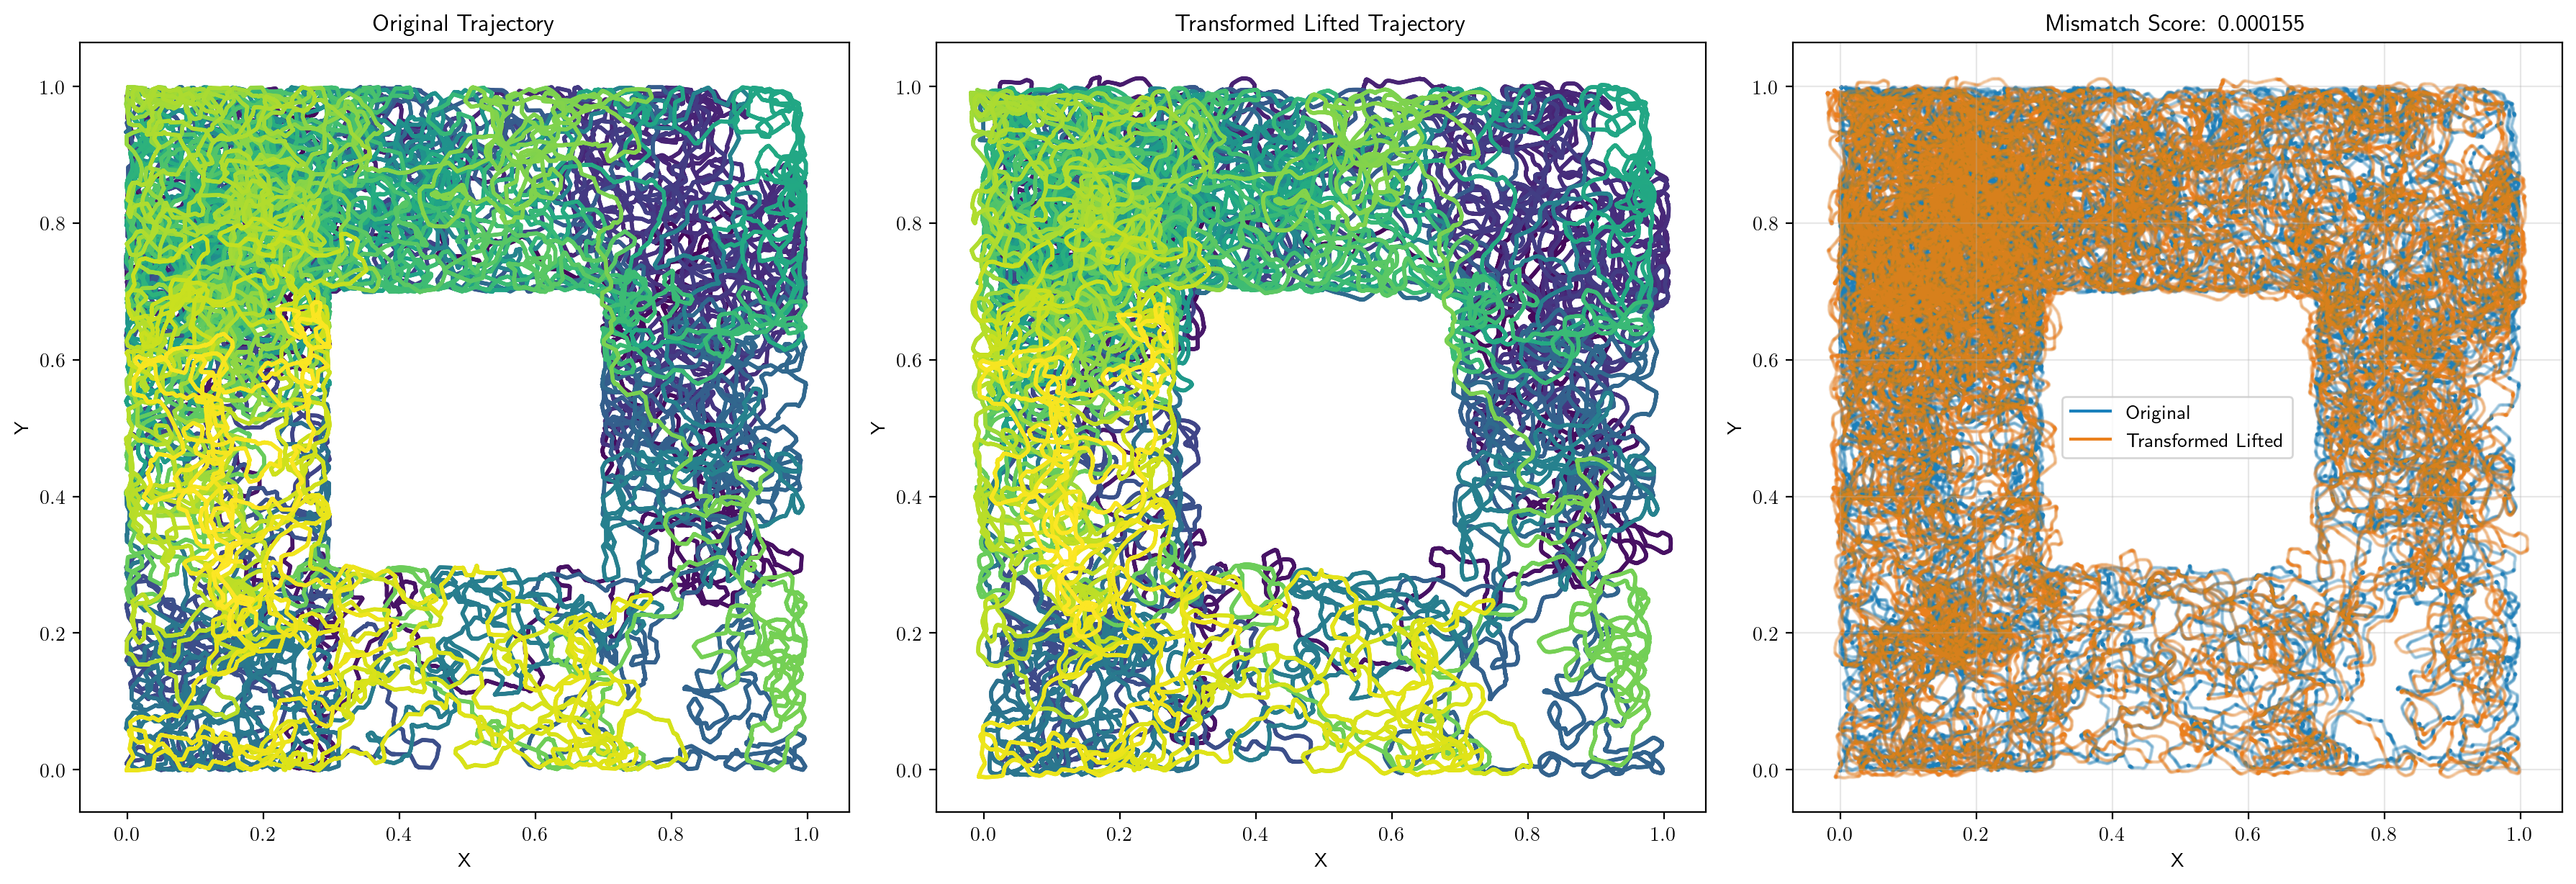

In [44]:
plot_trajectory_comparison(processed_trace, lifted_coord_transformed, score_gardner)

## 5. Plot segments

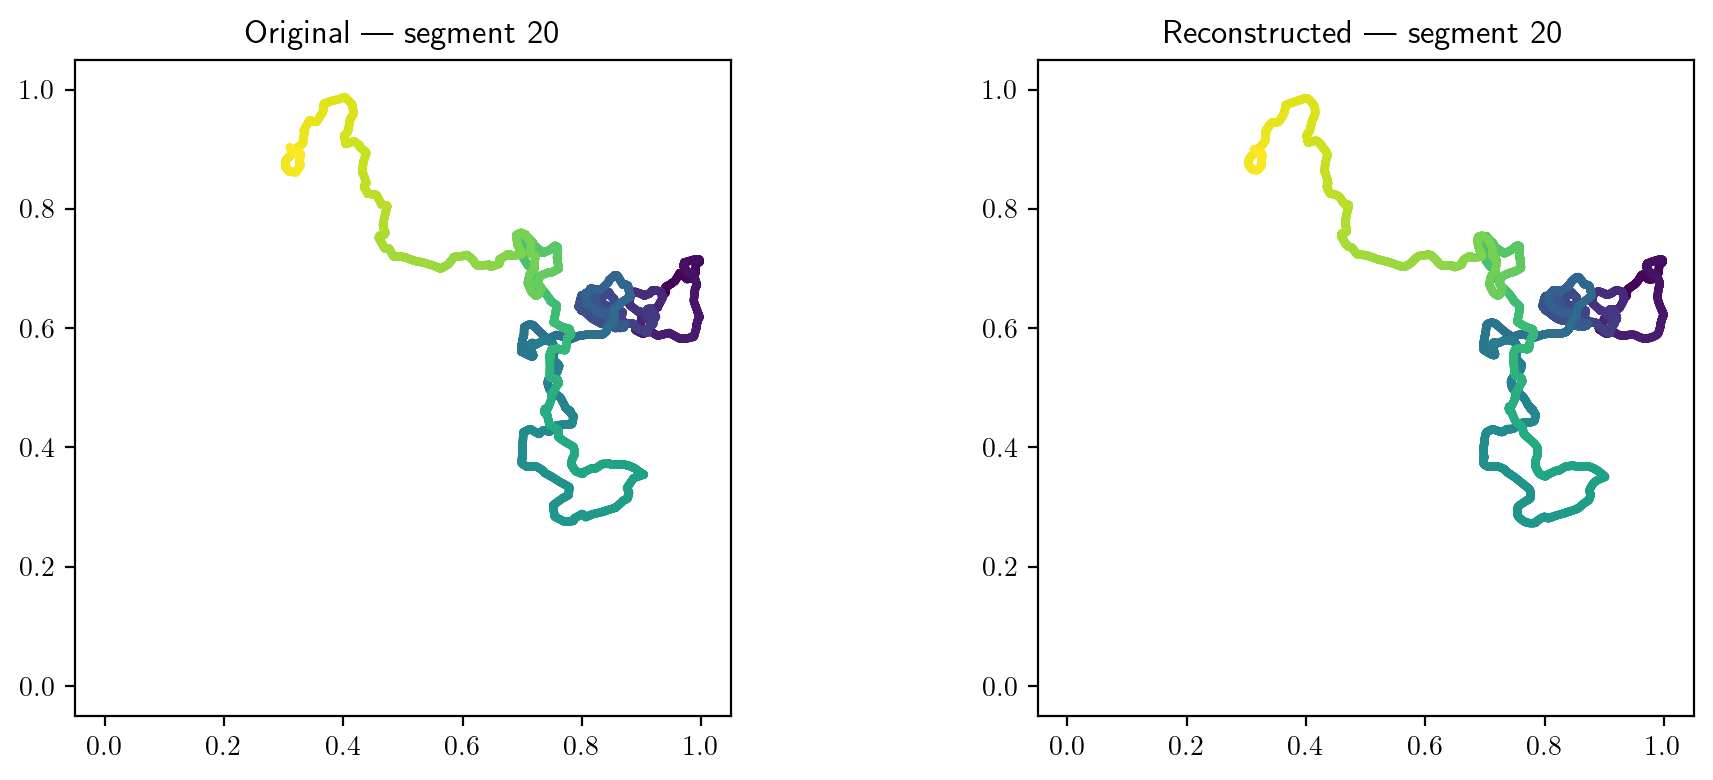

In [45]:
SEG_LEN = 10000 

# Choose segment index to plot
i = 20

orig_seg = processed_trace[i * SEG_LEN : (i + 1) * SEG_LEN]
lifted_seg  = lifted_coord_transformed[i * SEG_LEN : (i + 1) * SEG_LEN]
transform_mat = get_transform_mat(lifted_seg, orig_seg)
lifted_transformed_seg = apply_transform_mat(lifted_seg, transform_mat)

colors = plt.cm.viridis(np.linspace(0, 1, SEG_LEN))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(orig_seg[:, 0], orig_seg[:, 1], c=colors, s=4)
axes[0].set_title(f"Original — segment {i}")
axes[0].set_aspect("equal")
axes[0].set_xlim(-0.05, 1 + 0.05)
axes[0].set_ylim(-0.05, 1 + 0.05)

axes[1].scatter(lifted_transformed_seg[:, 0], lifted_transformed_seg[:, 1], c=colors, s=4)
axes[1].set_title(f"Reconstructed — segment {i}")
axes[1].set_aspect("equal")
axes[1].set_xlim(-0.05, 1 + 0.05)
axes[1].set_ylim(-0.05, 1 + 0.05)


fig.tight_layout()
plt.show()


In [46]:
seg_scores = segmental_mismatch(lifted_coord_transformed, processed_trace, SEG_LEN)
print(f"Number of segments: {len(seg_scores)}")
print(f"Segment scores: {seg_scores}")
print(f"Mean: {np.mean(seg_scores):.6f}  Std: {np.std(seg_scores):.6f}")


Number of segments: 59
Segment scores: [0.0066931998272266365, 0.008048301596896923, 0.006115809594537236, 0.005264528258837946, 0.012430445220167173, 0.004430677893446866, 0.011574714369834484, 0.009590540087015254, 0.010215967930885288, 0.011341938610445768, 0.012068403378002893, 0.005976682717753179, 0.008429084929535037, 0.0074603673751712455, 0.009371490387581316, 0.0057980387391300256, 0.005595370128218805, 0.0064477741230945995, 0.007427959891519883, 0.006485945192582998, 0.005971223754383567, 0.008670586500615397, 0.008138927214295254, 0.009132308227182473, 0.006886125182398068, 0.00919003196076911, 0.005808455878612724, 0.006146997305947918, 0.010760683298134538, 0.01442418672922159, 0.008923486631201726, 0.011644803334876158, 0.007584363289385825, 0.010043375892659932, 0.007186243971025877, 0.006316411848047237, 0.00639540766390232, 0.00831841477711332, 0.013611546897988316, 0.013511882947075159, 0.005789963830550884, 0.007014588611856611, 0.011873471184557578, 0.009191637717

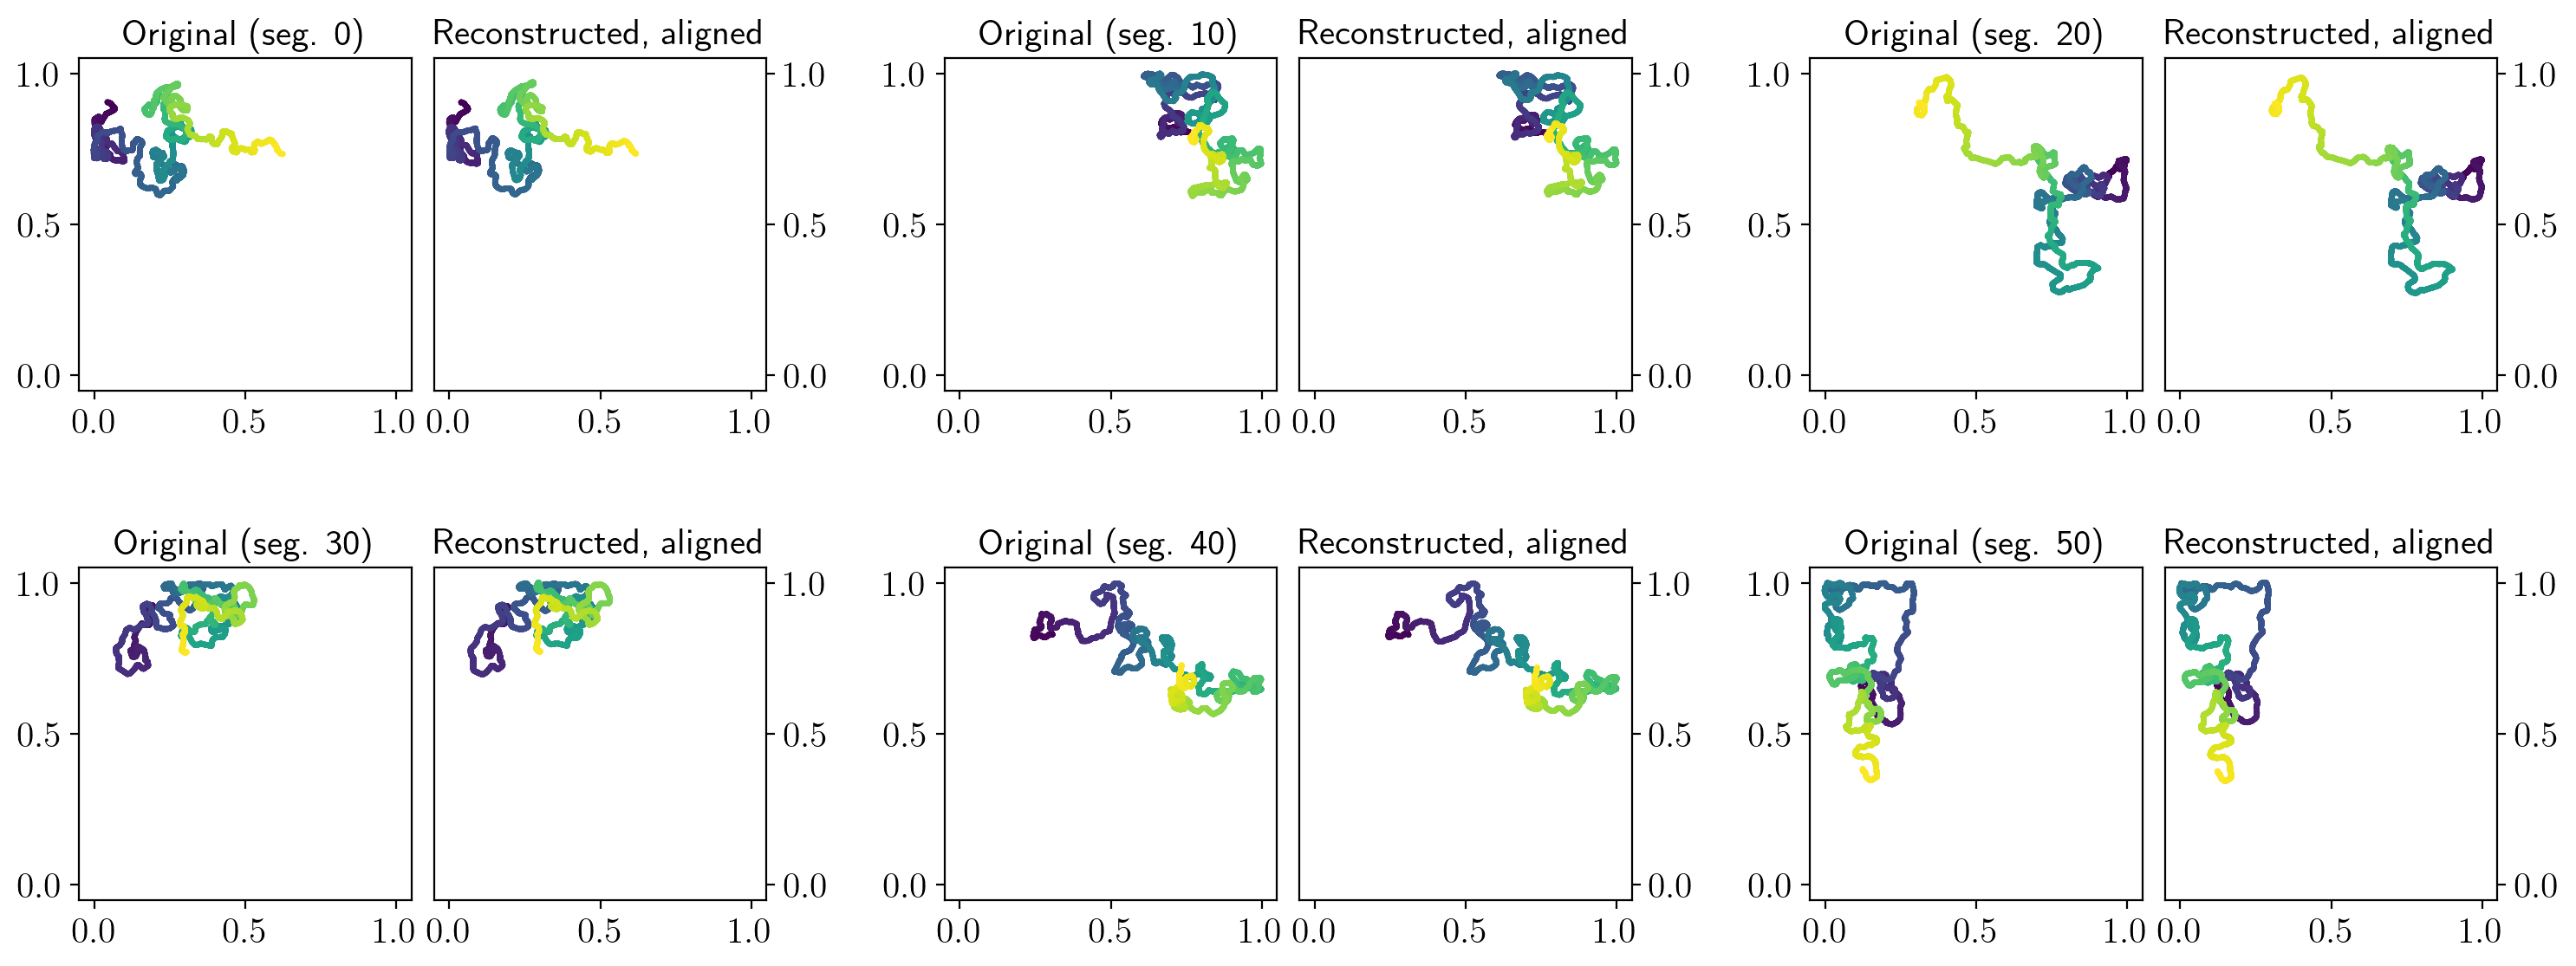

In [47]:

# plot 6 example segments in a 2-row grid (3 pairs per row)
# each pair: [original | reconstructed], with extra space between pairs

segments = list(range(0, 60, 10))  # [0, 10, 20, 30, 40, 50]
n_per_row = 3

# Column layout per row: [orig, rec, spacer, orig, rec, spacer, orig, rec]
# width_ratios: pair cols = 1, spacer cols = 0.4
col_widths = []
for k in range(n_per_row):
    col_widths += [1, 1]
    if k < n_per_row - 1:
        col_widths.append(0.4)  # spacer between pairs

fig = plt.figure(figsize=(18, 7))
gs = GridSpec(2, len(col_widths), figure=fig,
              width_ratios=col_widths, wspace=0.08, hspace=0.2)

# Map pair index to actual column indices (skipping spacers)
pair_col_starts = [k * 3 for k in range(n_per_row)]  # 0, 3, 6

for idx, i in enumerate(segments):
    row = idx // n_per_row
    pair = idx % n_per_row
    c0 = pair_col_starts[pair]

    ax_orig = fig.add_subplot(gs[row, c0])
    ax_rec  = fig.add_subplot(gs[row, c0 + 1])

    orig_seg = processed_trace[i * SEG_LEN : (i + 1) * SEG_LEN]
    lifted_seg = lifted_coord_transformed[i * SEG_LEN : (i + 1) * SEG_LEN]
    transform_mat = get_transform_mat(lifted_seg, orig_seg)
    lifted_transformed_seg = apply_transform_mat(lifted_seg, transform_mat)

    colors = plt.cm.viridis(np.linspace(0, 1, SEG_LEN))

    ax_orig.scatter(orig_seg[:, 0], orig_seg[:, 1], c=colors, s=2)
    ax_orig.set_title(f"Original (seg. {i})", fontsize=15)
    ax_orig.set_aspect("equal")
    ax_orig.set_xlim(-0.05, 1.05)
    ax_orig.set_ylim(-0.05, 1.05)
    ax_orig.set_xticks([0, 0.5, 1])
    ax_orig.set_yticks([0, 0.5, 1])
    ax_orig.tick_params(labelsize=15)

    ax_rec.scatter(lifted_transformed_seg[:, 0], lifted_transformed_seg[:, 1], c=colors, s=2)
    ax_rec.set_title(f"Reconstructed, aligned", fontsize=15)
    ax_rec.set_aspect("equal")
    ax_rec.set_xlim(-0.05, 1.05)
    ax_rec.set_ylim(-0.05, 1.05)
    ax_rec.set_xticks([0, 0.5, 1])
    ax_rec.set_yticks([0, 0.5, 1])
    ax_rec.yaxis.set_label_position("right")
    ax_rec.yaxis.tick_right()
    ax_rec.tick_params(labelsize=15)

plt.show()
